In [3]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(14.4,7.4)



In [4]:
# load cross-section from uncertainty

energy_t = np.array([
    1.000000E-02, 2.000000E-02, 3.000000E-02, 4.000000E-02, 5.000000E-02,
    6.000000E-02, 7.000000E-02, 8.000000E-02, 9.000000E-02, 1.000000E-01,
    1.500000E-01, 2.000000E-01, 2.500000E-01, 3.000000E-01, 3.500000E-01,
    4.000000E-01, 4.500000E-01, 5.000000E-01, 5.500000E-01, 6.000000E-01,
    6.500000E-01, 7.000000E-01, 7.500000E-01, 8.000000E-01, 8.500000E-01,
    9.000000E-01, 9.500000E-01, 1.000000E+00, 1.500000E+01
])

# cross-section - widthmode 1 
# cross-section 2 - widthmode 0


#func_rand1 = np.loadtxt('cross-section.txt')
#func_rand2 = np.loadtxt('cross-section-2.txt')
#func_rand3 = np.loadtxt('cross-section-3.txt')

#func_rand = np.loadtxt('cross-section-no96.txt')

#func_rand =np.vstack((func_rand1,func_rand2))

func_rand =  np.loadtxt('cross-section.txt')

print(func_rand.shape)

print(func_rand)

(100, 29)
[[111.7973     63.17517    45.38787   ...   0.8995037   0.8264121
    0.4331941]
 [197.8964    116.19       84.24335   ...   2.149237    1.974461
    0.6694514]
 [117.241      66.5076     47.82409   ...   1.042628    0.9589867
    0.4735373]
 ...
 [114.6012     64.8748     46.65323   ...   1.073839    0.9914969
    0.3943088]
 [110.4312     62.58559    45.01627   ...   1.061355    0.97753
    0.4920173]
 [127.5657     72.7752     52.35845   ...   1.129914    1.032818
    0.5858675]]


In [5]:
# talys all combinations
xs_comb_up =  np.loadtxt('xs-comb-up 1.txt')
print(xs_comb_up.shape)

xs_comb_down =  np.loadtxt('xs-comb-down 1.txt')
print(xs_comb_down.shape)


xs_comb =np.vstack((xs_comb_up,xs_comb_down))
print(xs_comb.shape)


(60, 29)
(60, 29)
(120, 29)


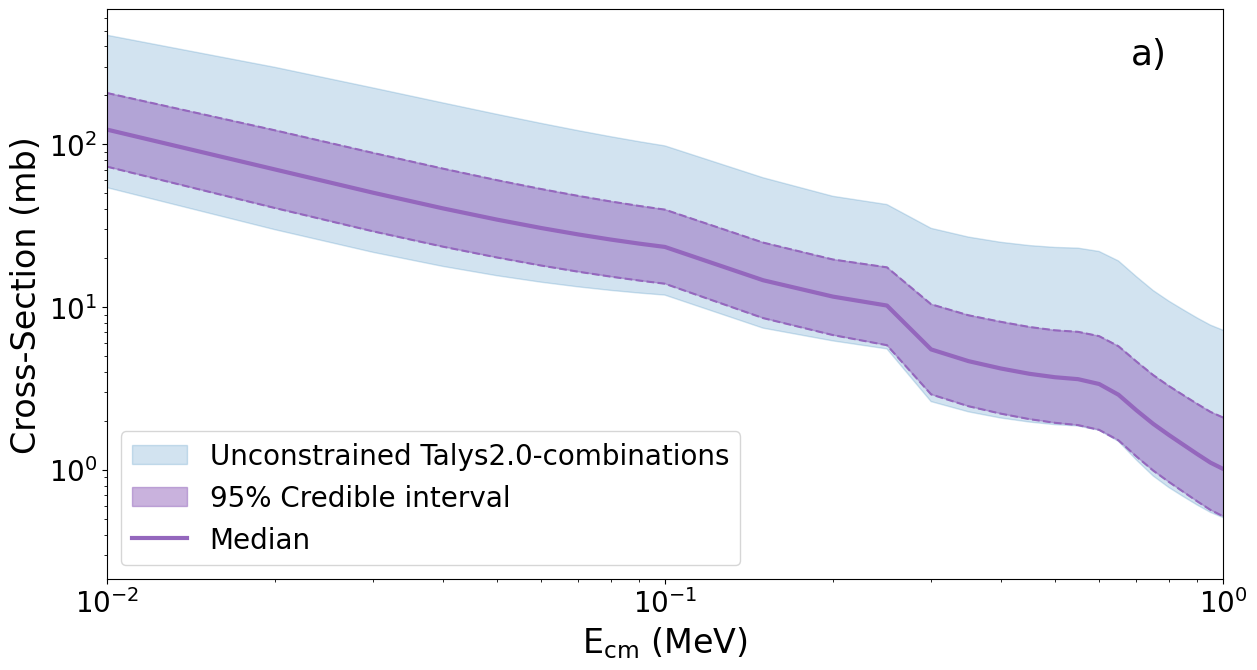

In [15]:
#plot both together 
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
fig = plt.figure()


upper_comb = (np.percentile(xs_comb, 100, axis = 0))
lower_comb = (np.percentile(xs_comb, 0, axis = 0))
plt.fill_between(energy_t, lower_comb, upper_comb, color=colors[0], alpha=0.2,label='Unconstrained Talys2.0-combinations')





median = np.percentile(func_rand, 50, axis = 0)
upper = (np.percentile(func_rand, 97.5, axis = 0))

prediction_color_number=4

lower = (np.percentile(func_rand, 2.5, axis = 0))


plt.fill_between(energy_t, lower, upper, color=colors[prediction_color_number], alpha=0.5,label='95% Credible interval')


plt.plot(energy_t, median, color=colors[prediction_color_number],linewidth=3,label='Median')
plt.plot(energy_t, lower, color=colors[prediction_color_number],linestyle='dashed')
plt.plot(energy_t, upper, color=colors[prediction_color_number],linestyle='dashed')




'''
plt.errorbar(df1['energy'], df1['xs'],yerr= df1['dxs'],fmt="o", color="r",ecolor='r',label='2011 Tagliente et al.',linestyle='None')
plt.errorbar(df2['energy'], df2['xs'],yerr= df2['dxs'],fmt="s", color="b",ecolor='b',label='2018 S.Badwar et al.',linestyle='None')
plt.errorbar(df3['energy'], df3['xs'],yerr= df3['dxs'],xerr=df3['denergy'],fmt="^", color="brown",ecolor='brown',label='2011 Katabuchi et al.',linestyle='None')
plt.errorbar(df4['energy'], df4['xs'],yerr= df4['dxs'],xerr=df4['denergy'],fmt="+", color="olive",ecolor='olive',label='1982 Wyrich et al.',linestyle='None')
plt.errorbar(df5['energy'], df5['xs'],yerr= df5['dxs'],xerr=df5['denergy'],fmt="*", color="green",ecolor='green',label='1959 Lyon et al.',linestyle='None')
plt.errorbar(df6['energy'], df6['xs'],yerr= df6['dxs'],fmt="x", color="black",ecolor='black',label='1990 Toukan et al.',linestyle='None')
'''

#plt.plot(dfd_['energy'], dfd_['xs'],color='green',marker='*',label= 'cross-section-talys ',linewidth=6)
#plt.plot(dfd_2['energy'], dfd_2['xs'],color='green',marker='*',label= 'cross-section-ld5 ptable =0.5')

#plt.plot(dfd_2['energy'], dfd_2['xs'],color='purple',marker='*',label= '96Zr(n,g) oslo -elevated gsf')


'''
for i in range(96):
    plt.plot(energy_t, xs_comb[i], color='blue')
'''


plt.yscale("log")
plt.xscale("log")

plt.xlabel("E$_{\mathrm{cm}}$ (MeV)", fontsize=24)
plt.ylabel("Cross-Section (mb)",fontsize = 24) 
#plt.title("Cross-Section",fontsize = 15)    

plt.xlim(0.01,1)
#plt.ylim(3,100)

plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)

#plt.ylim(10**(-9),10**(-4))

#plt.text(0.95, 0.05, 'a)', transform=plt.gca().transAxes,
#         fontsize=24, va='bottom', ha='right')
plt.legend(loc ='lower left',fontsize=20)


plt.text(
    0.95, 0.95, 'a)',
    transform=plt.gca().transAxes,
    fontsize=26,
    va='top',
    ha='right'
)

#plt.savefig(r"cross-section.jpg", format='jpg', dpi=300, bbox_inches='tight')

plt.show()
